# Load and Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
df = pd.read_csv('../data/usa_housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [5]:
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nBasic Info:')
df.info()

Dataset Shape: 5000 rows x 7 columns

Data Types:
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                          object
dtype: object

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes

In [8]:
df.describe()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


In [9]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing Values:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Total missing values: 0

Duplicate rows: 0


## 2. Target Variable Analysis

The target variable is **Price**, the selling price of the house. We examine its distribution to understand the range, central tendency, and spread of house prices.

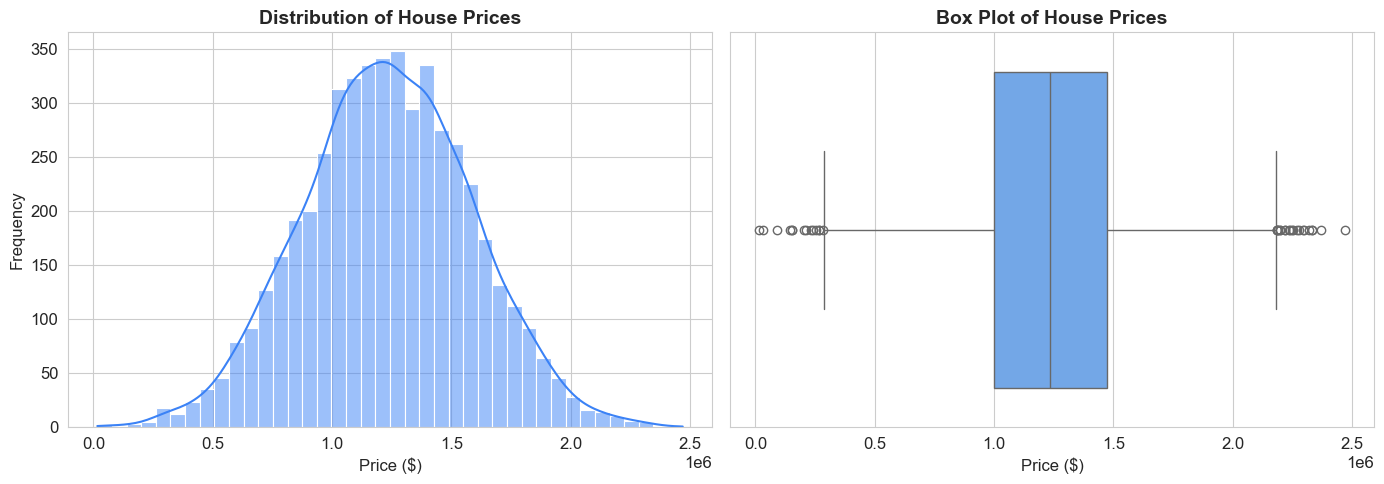

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['Price'], bins=40, kde=True, ax=axes[0], color='#3B82F6', edgecolor='white')
axes[0].set_title('Distribution of House Prices', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# Box plot
sns.boxplot(x=df['Price'], ax=axes[1], color='#60A5FA')
axes[1].set_title('Box Plot of House Prices', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
print('House Price Statistics:')
print(f'  Mean:   ${df["Price"].mean():,.2f}')
print(f'  Median: ${df["Price"].median():,.2f}')
print(f'  Min:    ${df["Price"].min():,.2f}')
print(f'  Max:    ${df["Price"].max():,.2f}')
print(f'  Std:    ${df["Price"].std():,.2f}')
print(f'  Skewness: {df["Price"].skew():.4f}')
print(f'  Kurtosis: {df["Price"].kurtosis():.4f}')

House Price Statistics:
  Mean:   $1,232,072.65
  Median: $1,232,669.38
  Min:    $15,938.66
  Max:    $2,469,065.59
  Std:    $353,117.63
  Skewness: -0.0027
  Kurtosis: -0.0549


## 3. Feature Distributions

Understanding the distribution of each feature helps identify skewness, outliers, and potential data quality issues.

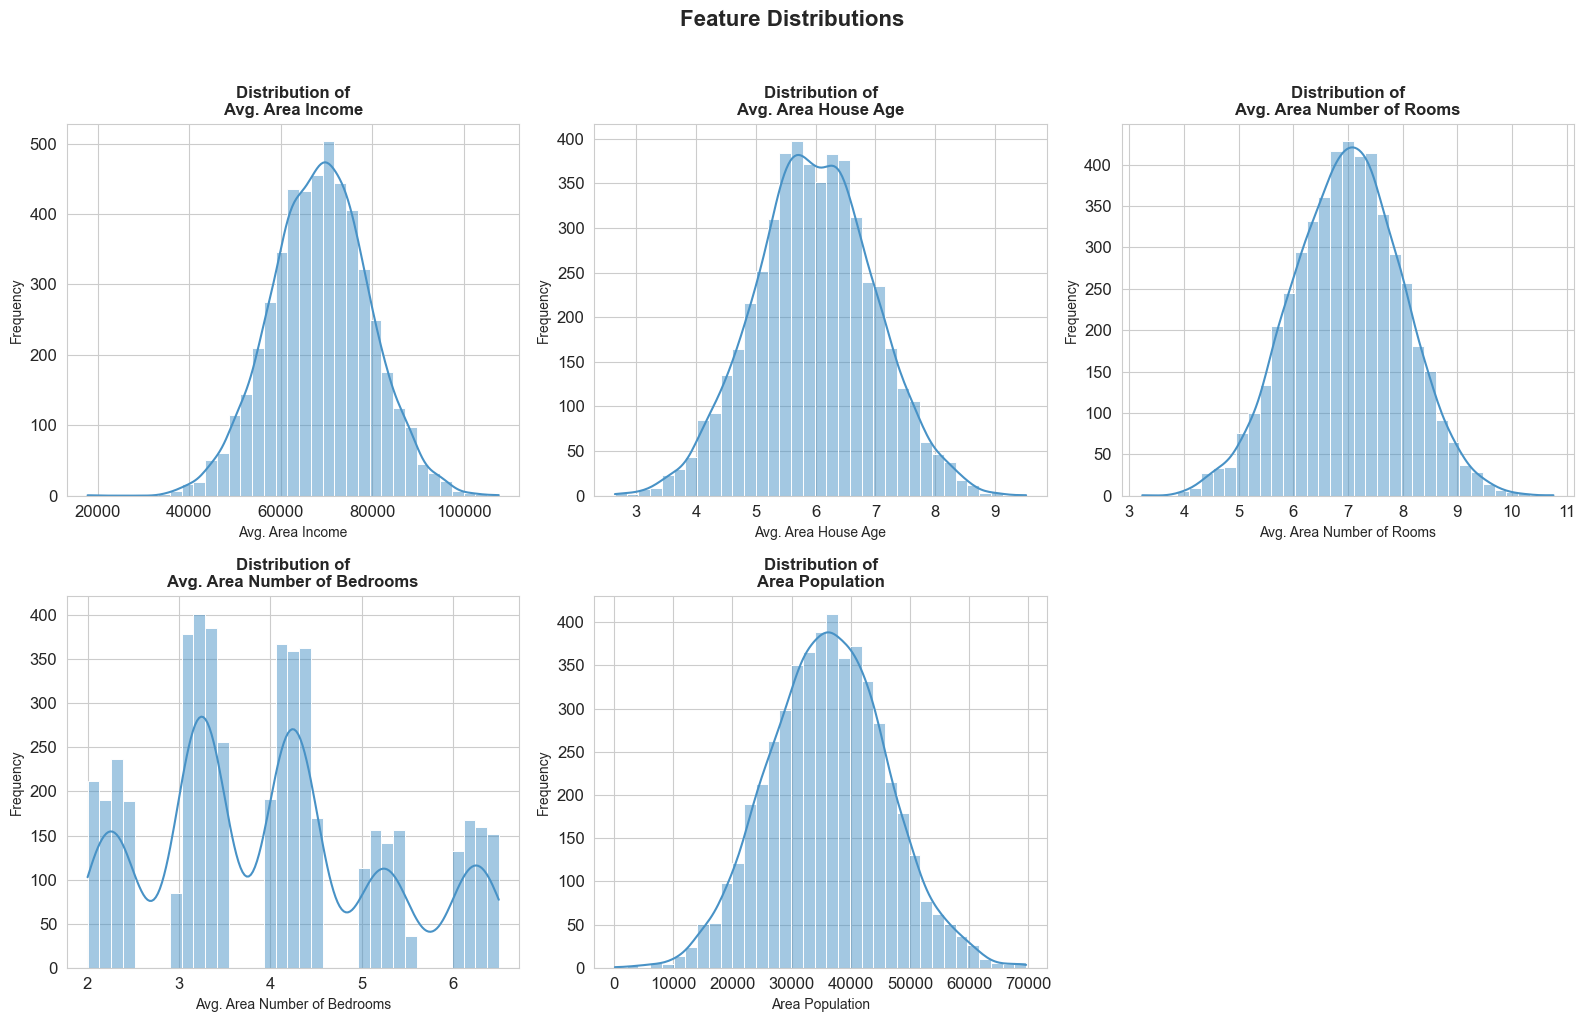

In [13]:
# Feature distributions
numerical_features = ['Avg. Area Income', 'Avg. Area House Age', 
                      'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 
                      'Area Population']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], bins=35, kde=True, ax=axes[i], 
                 color=sns.color_palette('Blues_d')[2], edgecolor='white')
    axes[i].set_title(f'Distribution of\n{feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)

axes[5].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

Correlation analysis reveals how strongly each feature relates to the target variable (Price) and to each other.

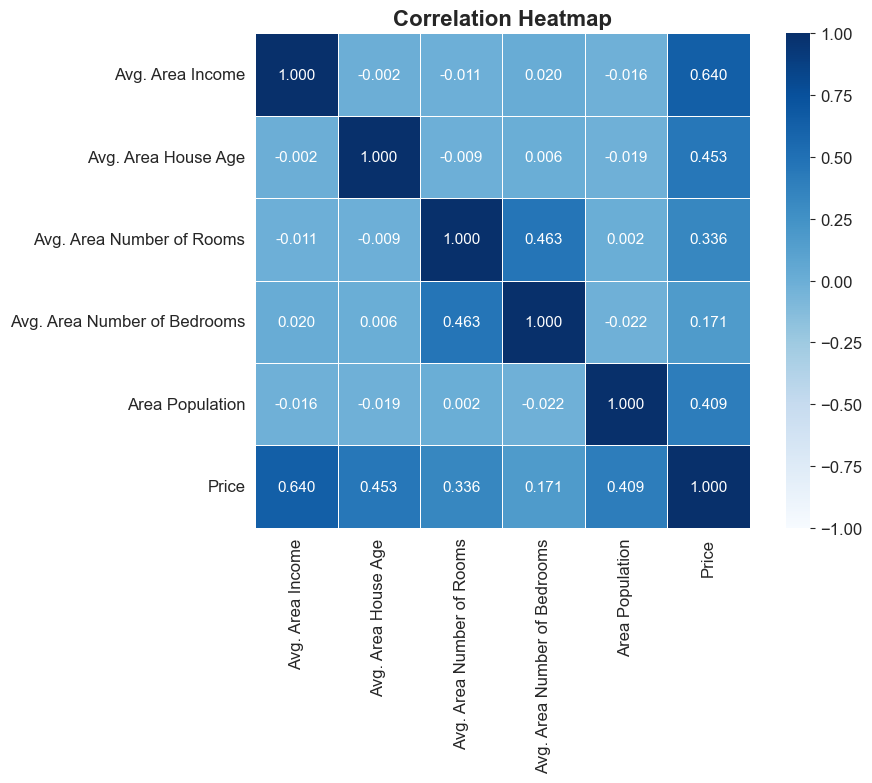

In [14]:
numerical_df = df[numerical_features + ['Price']]
corr_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.3f', 
            linewidths=0.5, square=True, vmin=-1, vmax=1,
            annot_kws={'size': 11})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Correlation with Price (sorted):
  Avg. Area Income                         0.6397
  Avg. Area House Age                      0.4525
  Area Population                          0.4086
  Avg. Area Number of Rooms                0.3357
  Avg. Area Number of Bedrooms             0.1711


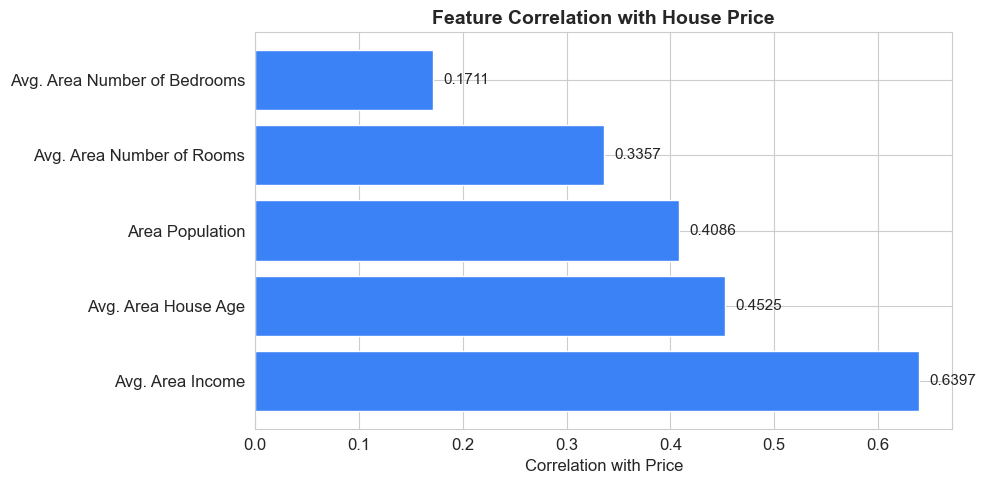

In [15]:
price_corr = corr_matrix['Price'].drop('Price').sort_values(ascending=False)
print('Correlation with Price (sorted):')
for feature, corr in price_corr.items():
    print(f'  {feature:40s} {corr:.4f}')

plt.figure(figsize=(10, 5))
bars = plt.barh(price_corr.index, price_corr.values, color='#3B82F6', edgecolor='white')
plt.xlabel('Correlation with Price', fontsize=12)
plt.title('Feature Correlation with House Price', fontsize=14, fontweight='bold')
for bar, val in zip(bars, price_corr.values):
    plt.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
             va='center', fontsize=11)
plt.tight_layout()
plt.show()

## 5. Scatter Plots - Price vs Features

Scatter plots help visualize the relationship between each feature and the target variable.

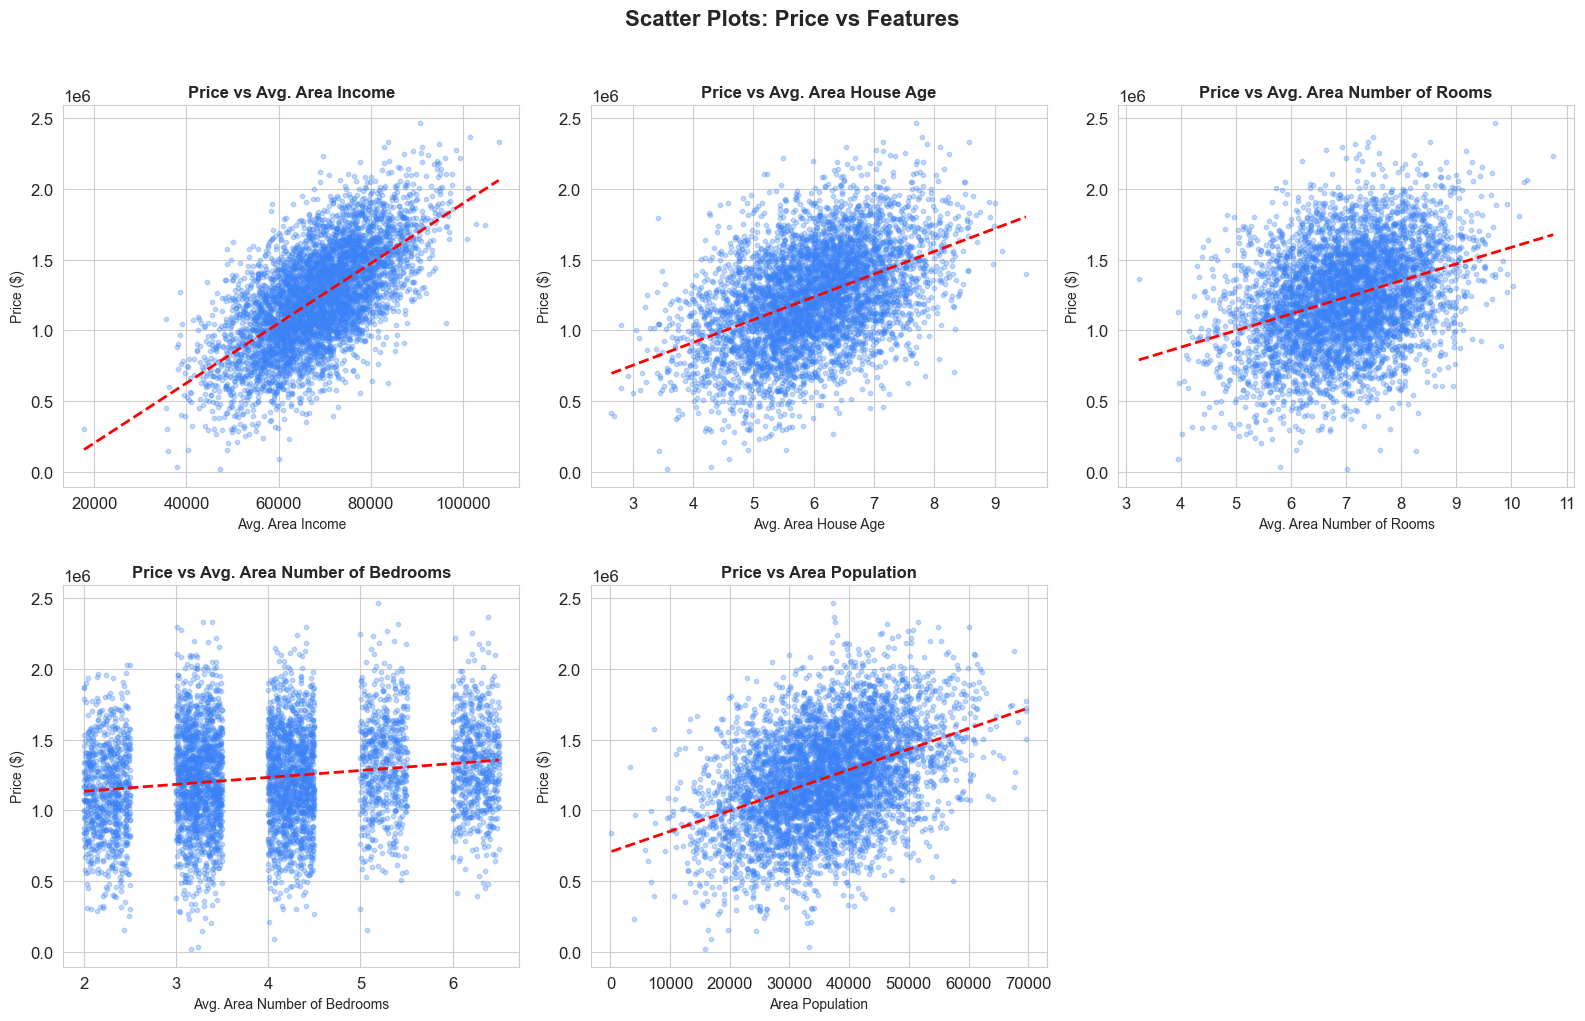

In [17]:
# Scatter plots: Price vs each feature
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].scatter(df[feature], df['Price'], alpha=0.3, s=10, color='#3B82F6')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Price ($)', fontsize=10)
    axes[i].set_title(f'Price vs {feature}', fontsize=12, fontweight='bold')
    
    # Add trend line
    z = np.polyfit(df[feature], df['Price'], 1)
    p = np.poly1d(z)
    x_sorted = np.sort(df[feature])
    axes[i].plot(x_sorted, p(x_sorted), color='red', linewidth=2, linestyle='--')

axes[5].set_visible(False)

plt.suptitle('Scatter Plots: Price vs Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

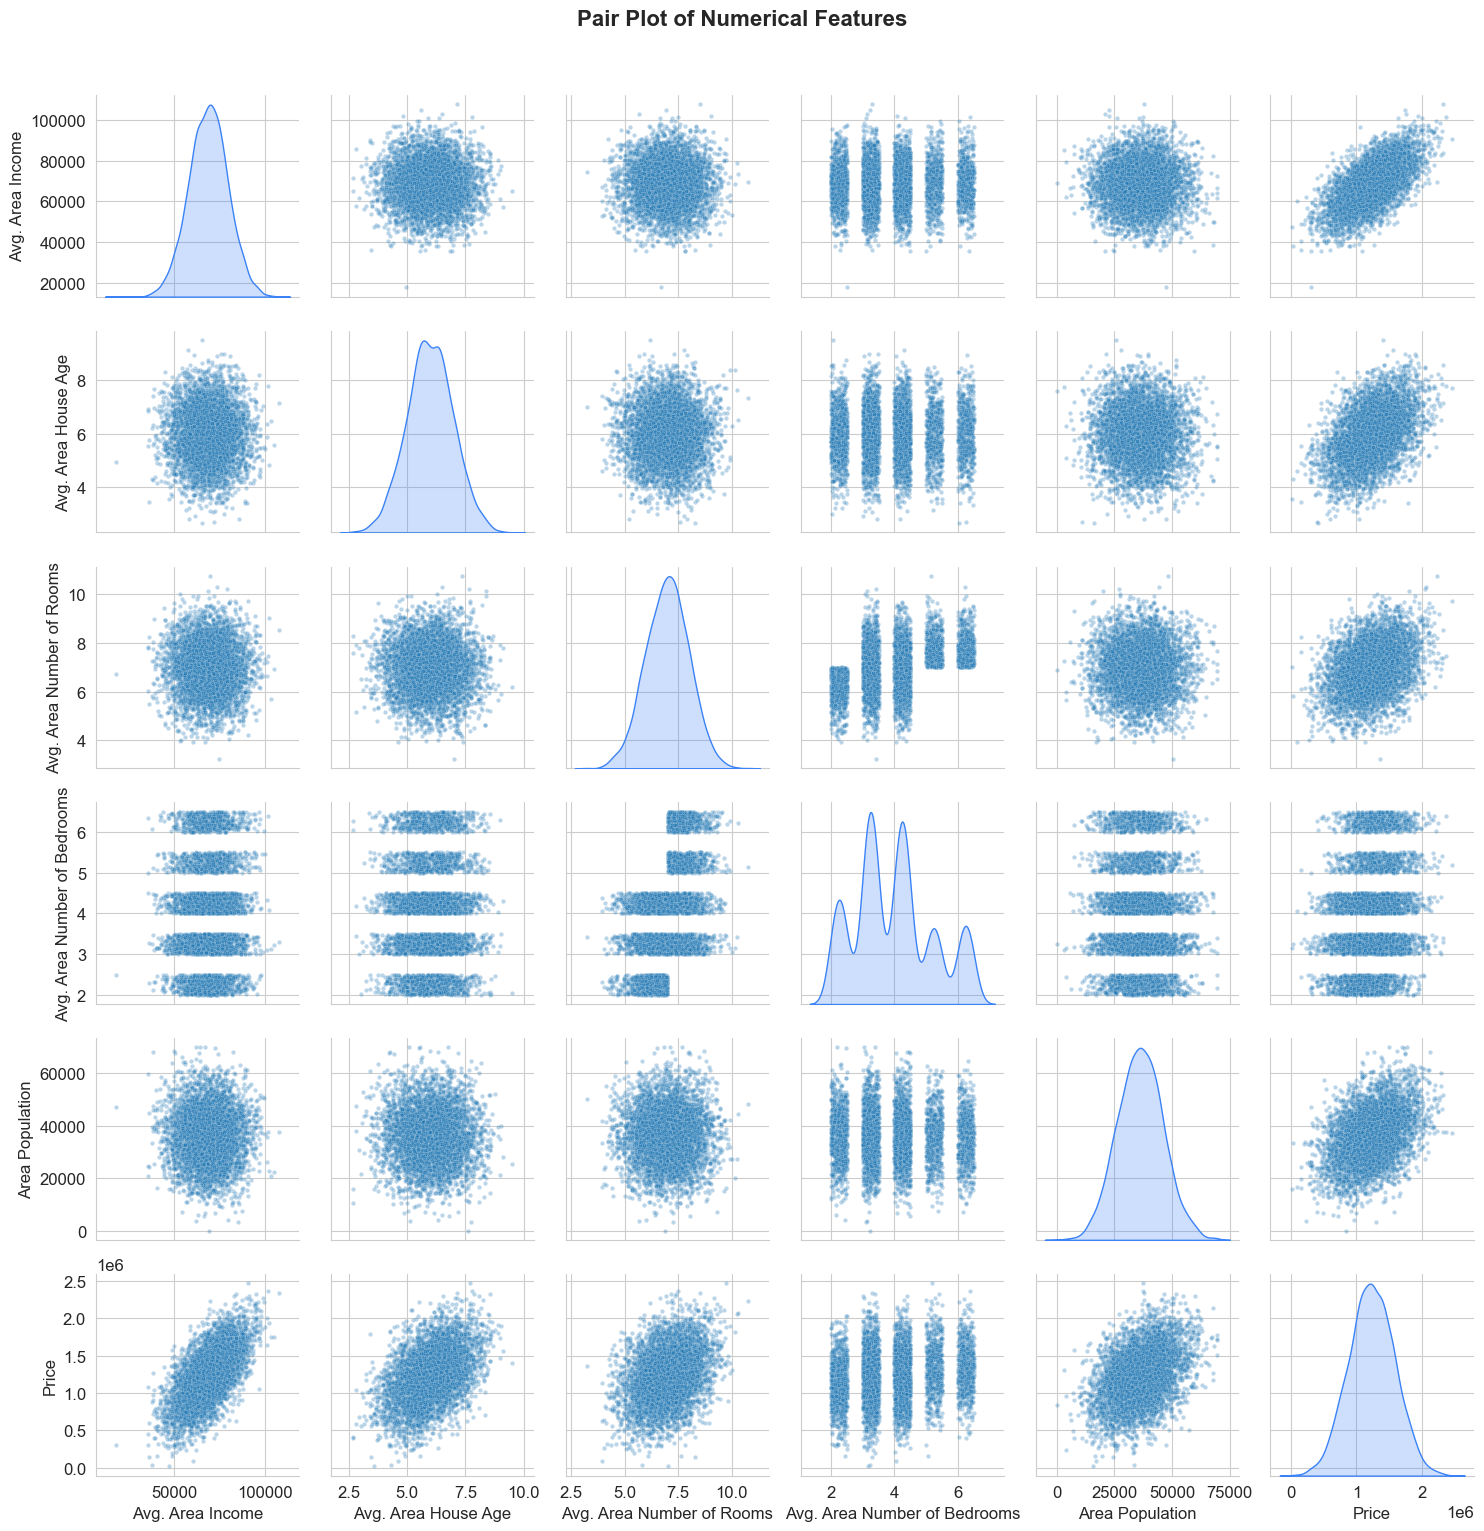

In [18]:
# Pair plot for deeper relationship analysis
sns.pairplot(numerical_df, diag_kind='kde', 
             plot_kws={'alpha': 0.3, 's': 10},
             diag_kws={'color': '#3B82F6'})
plt.suptitle('Pair Plot of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Key Findings

### Most Important Features
Based on the correlation analysis, **Avg. Area Income** has the strongest correlation with Price (~0.64), followed by **Avg. Area House Age** (~0.45), **Area Population** (~0.41), and **Avg. Area Number of Rooms** (~0.34). **Avg. Area Number of Bedrooms** has the weakest correlation (~0.17) and may be a candidate for exclusion.

### Linearity of Relationships
The scatter plots show that the relationships between features and Price are predominantly **linear**. The trend lines fit well, and there is no strong evidence of non-linear patterns. This suggests that linear regression models should perform well, and polynomial features might capture some additional variance.

### Feature Selection
We will include all five numerical features in the initial model since even the weakest feature (Avg. Area Number of Bedrooms) still has a positive correlation. However, we may experiment with removing it to see if model performance improves. The **Address** column is excluded as it is a text identifier with no predictive value.

### Recommended Model Types
1. **Linear Regression**: Strong baseline given the linear relationships observed
2. **Polynomial Regression + Ridge**: May capture slight non-linearities while Ridge regularization prevents overfitting
3. **KNN Regressor**: Non-parametric alternative that can capture local patterns

### Data Quality
- No missing values detected across all columns
- No duplicate rows found
- Price distribution is approximately normal (slight right skew)
- No extreme outliers that would require removal
- All numerical features are approximately normally distributed